# Random Variables, PMF, PDF, and CDF

This notebook builds intuition for four core probability ideas:

1. **Random Variable** — a number produced by a random experiment.
2. **PMF** — probability mass function for **discrete** random variables.
3. **PDF** — probability density function for **continuous** random variables.
4. **CDF** — cumulative distribution function, useful for both discrete and continuous random variables.

We will use simulations and visualizations rather than only formulas.

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Random Variable

A **random variable** is not the random process itself. It is a numerical value assigned to the outcome of a random process.

Example:

- Experiment: roll one fair die.
- Outcome: one of `{1, 2, 3, 4, 5, 6}`.
- Random variable `X`: the number shown on the die.

So `X` can take values `1` to `6`.

In [86]:
# Simulate rolling one fair die many times

n = 10_000
die_rolls = rng.integers(1, 7, size=n)

die_rolls[:20]

array([1, 5, 4, 3, 3, 6, 1, 5, 2, 1, 4, 6, 5, 5, 5, 5, 4, 1, 6, 3])

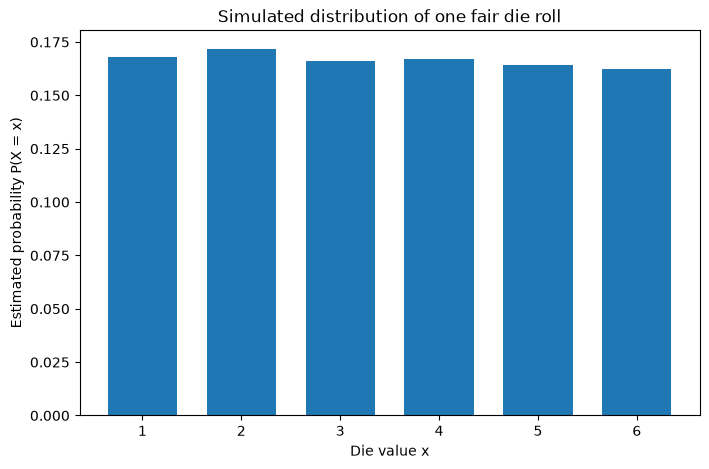

{np.int64(1): np.float64(0.168),
 np.int64(2): np.float64(0.172),
 np.int64(3): np.float64(0.166),
 np.int64(4): np.float64(0.167),
 np.int64(5): np.float64(0.164),
 np.int64(6): np.float64(0.162)}

In [87]:
values, counts = np.unique(die_rolls, return_counts=True)
estimated_probs = counts / n

plt.bar(values, estimated_probs, width=0.7)
plt.xticks(values)
plt.xlabel("Die value x")
plt.ylabel("Estimated probability P(X = x)")
plt.title("Simulated distribution of one fair die roll")
plt.show()

dict(zip(values, estimated_probs.round(3)))

The bars are close to `1/6` each because each die face is equally likely.

This is a **discrete random variable** because it can take only separate values: `1, 2, 3, 4, 5, 6`.

## 2. PMF: Probability Mass Function

For a **discrete** random variable, the **PMF** is a function that assigns a probability to each possible value:

$$
p(x) = P(X = x)
$$

This reads: the probability that $X$ takes exactly the value $x$.

For a fair die, each face is equally likely:

$$
P(X = x) = \frac{1}{6}, \quad x \in \{1, 2, 3, 4, 5, 6\}
$$

Every valid PMF must satisfy the **normalization condition**:

$$
\sum_{x} P(X = x) = 1
$$

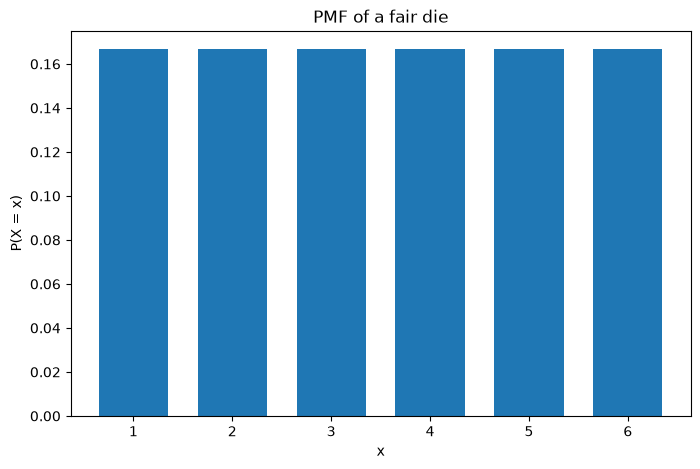

np.float64(0.9999999999999999)

In [88]:
# Theoretical PMF for a fair die

x = np.arange(1, 7)
pmf = np.ones(6) / 6

plt.bar(x, pmf, width=0.7)
plt.xticks(x)
plt.xlabel("x")
plt.ylabel("P(X = x)")
plt.title("PMF of a fair die")
plt.show()

pmf.sum()

### PMF example: biased coin

Let `X = number of heads in 3 coin flips`.

Suppose the coin has:

$$
P(H) = 0.7
$$

Then `X` can be:

$$
0, 1, 2, 3
$$

This is a **Binomial** random variable.

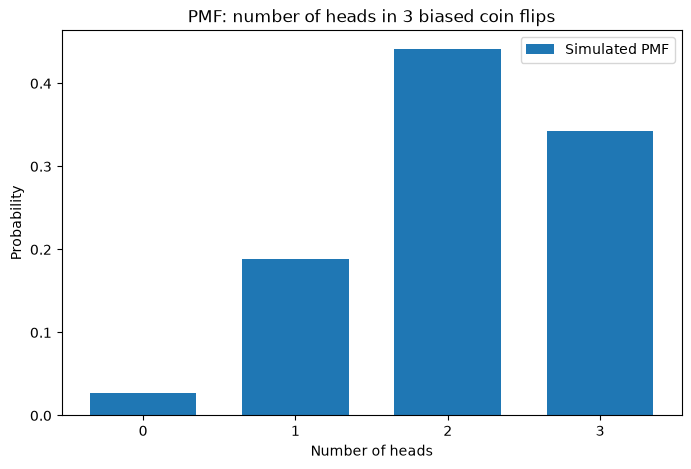

{np.int64(0): np.float64(0.0276),
 np.int64(1): np.float64(0.1884),
 np.int64(2): np.float64(0.4416),
 np.int64(3): np.float64(0.3424)}

In [89]:
# Simulate number of heads in 3 biased coin flips

p_heads = 0.7
n_trials = 3
n_experiments = 100_000

flips = rng.random((n_experiments, n_trials)) < p_heads
heads_count = flips.sum(axis=1)

values, counts = np.unique(heads_count, return_counts=True)
simulated_pmf = counts / n_experiments

plt.bar(values, simulated_pmf, width=0.7, label="Simulated PMF")
plt.xticks(values)
plt.xlabel("Number of heads")
plt.ylabel("Probability")
plt.title("PMF: number of heads in 3 biased coin flips")
plt.legend()
plt.show()

dict(zip(values, simulated_pmf.round(4)))

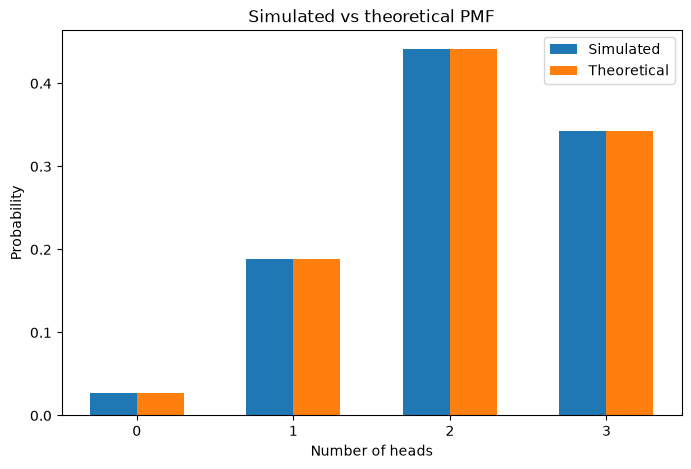

np.float64(1.0)

In [90]:
# Theoretical PMF using the binomial formula:
# P(X = k) = C(n, k) p^k (1-p)^(n-k)

k_values = np.arange(0, n_trials + 1)
theoretical_pmf = np.array([
    comb(n_trials, k) * (p_heads ** k) * ((1 - p_heads) ** (n_trials - k))
    for k in k_values
])

plt.bar(k_values - 0.15, simulated_pmf, width=0.3, label="Simulated")
plt.bar(k_values + 0.15, theoretical_pmf, width=0.3, label="Theoretical")
plt.xticks(k_values)
plt.xlabel("Number of heads")
plt.ylabel("Probability")
plt.title("Simulated vs theoretical PMF")
plt.legend()
plt.show()

theoretical_pmf.sum()

## 3. Continuous Random Variable

A **continuous random variable** can take infinitely many possible values in an interval.

Example:

- `X = waiting time for a bus`
- `X = height of a person`
- `X = measurement error`
- `X = temperature`

For continuous variables:

$$
P(X = \text{exact value}) = 0
$$

That sounds strange at first, but it means probability is assigned to **intervals**, not exact points.

For example:

$$
P(0 \le X \le 1)
$$

has meaning, but:

$$
P(X = 0.5317249)
$$

is usually zero.

## 4. PDF: Probability Density Function

For a continuous random variable, the **PDF** is not direct probability.

A PDF gives **density**.

Probability is the **area under the PDF curve** over an interval:

$$
P(a \le X \le b) = \int_a^b f(x)\,dx
$$

The total area under the PDF must be 1:

$$
\int_{-\infty}^{\infty} f(x)\,dx = 1
$$

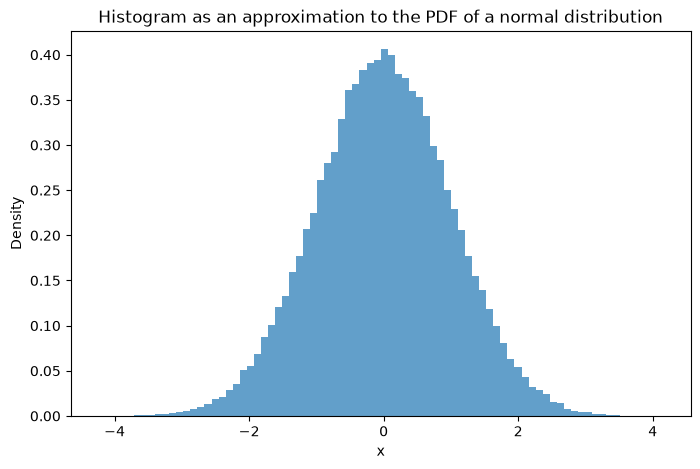

In [91]:
# Simulate a standard normal random variable

samples = rng.normal(loc=0, scale=1, size=100_000)

plt.hist(samples, bins=80, density=True, alpha=0.7)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram as an approximation to the PDF of a normal distribution")
plt.show()

The histogram is normalized using `density=True`.

That means the total area of the bars is approximately 1.
The height of a bar is **density**, not probability.

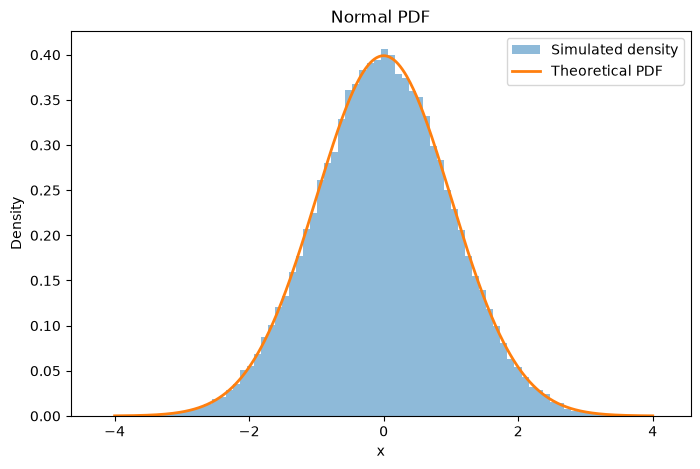

In [92]:
# Plot the theoretical normal PDF manually

x = np.linspace(-4, 4, 500)
normal_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

plt.hist(samples, bins=80, density=True, alpha=0.5, label="Simulated density")
plt.plot(x, normal_pdf, linewidth=2, label="Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Normal PDF")
plt.legend()
plt.show()

### Probability as area under the PDF

Let:

$$
X \sim N(0, 1)
$$

What is:

$$
P(-1 \le X \le 1)
$$

We can estimate it by simulation.

In [93]:
prob_between_minus1_and_1 = np.mean((-1 <= samples) & (samples <= 1))
prob_between_minus1_and_1

np.float64(0.68288)

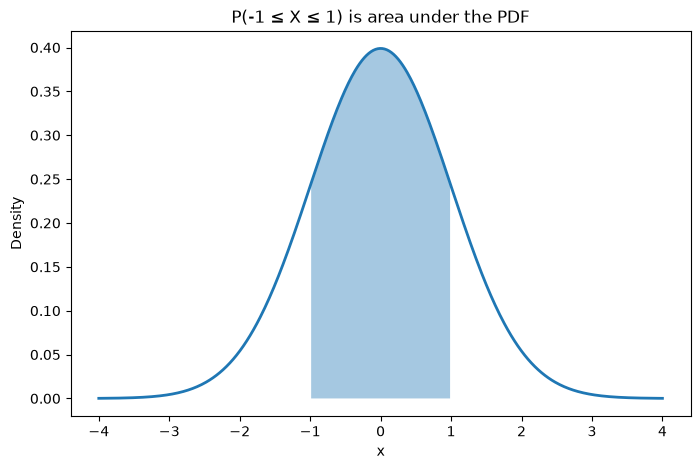

In [94]:
# Visualize this probability as area under the PDF

x = np.linspace(-4, 4, 500)
normal_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

mask = (-1 <= x) & (x <= 1)

plt.plot(x, normal_pdf, linewidth=2)
plt.fill_between(x[mask], normal_pdf[mask], alpha=0.4)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("P(-1 ≤ X ≤ 1) is area under the PDF")
plt.show()

For a standard normal random variable, this probability is about `0.68`.

This is the first number in the **68-95-99.7 rule**: for a normal distribution, approximately 68% of values fall within 1 standard deviation of the mean, 95% within 2, and 99.7% within 3.

## 5. CDF: Cumulative Distribution Function

The **CDF** applies to both discrete and continuous random variables. It is a function:

$$
F : \mathbb{R} \to [0, 1]
$$

defined as:

$$
F(x) = P(X \le x)
$$

### Properties

Every valid CDF satisfies three properties:

1. **Non-decreasing** — as $x$ increases, $F(x)$ never goes down
2. **Right limit** — $\lim_{x \to \infty} F(x) = 1$
3. **Left limit** — $\lim_{x \to -\infty} F(x) = 0$

### Interval probability

The probability that $X$ falls in an interval $(a, b]$ is the difference of CDF values:

$$
P(a < X \le b) = F(b) - F(a)
$$

The left endpoint is **open** because of how the CDF is defined. Expanding the right-hand side:

$$
F(b) - F(a) = P(X \le b) - P(X \le a)
$$

Subtracting $P(X \le a)$ removes everything up to and including $a$, so what remains is $P(a < X \le b)$.

To include $a$, you would need the left-hand limit $F(a^-) = P(X < a)$:

$$
P(a \le X \le b) = F(b) - F(a^-)
$$

For **continuous** variables this distinction never matters since $P(X = a) = 0$. For **discrete** variables it does — if $a$ is a valid value then $P(X = a) > 0$, so including or excluding it changes the answer.

### Discrete Random Variable

For discrete random variables, the CDF is a **step function** — it jumps at each possible value.

Using the biased coin example from Section 2 (3 flips, P(H) = 0.7):

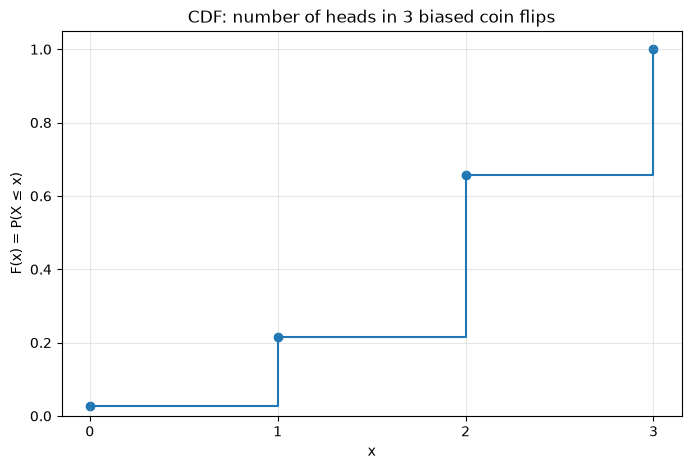

[(np.int64(0), np.float64(0.027)),
 (np.int64(1), np.float64(0.216)),
 (np.int64(2), np.float64(0.657)),
 (np.int64(3), np.float64(1.0))]

In [95]:
cdf = np.cumsum(theoretical_pmf)

plt.step(k_values, cdf, where="post")
plt.scatter(k_values, cdf)
plt.xticks(k_values)
plt.ylim(0, 1.05)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF: number of heads in 3 biased coin flips")
plt.grid(True, alpha=0.3)
plt.show()

list(zip(k_values, cdf.round(4)))

Example interpretation:

$$
F(2) = P(X \le 2)
$$

This means: probability of getting **at most 2 heads** in 3 biased coin flips.

In [96]:
prob_at_most_2 = cdf[2]
prob_more_than_2 = round(1 - float(prob_at_most_2), 4)

prob_at_most_2, prob_more_than_2

(np.float64(0.657), 0.343)

### Continuous Random Variable

For continuous random variables, the CDF is smooth and S-shaped — there are no jumps because there are no discrete probability masses.

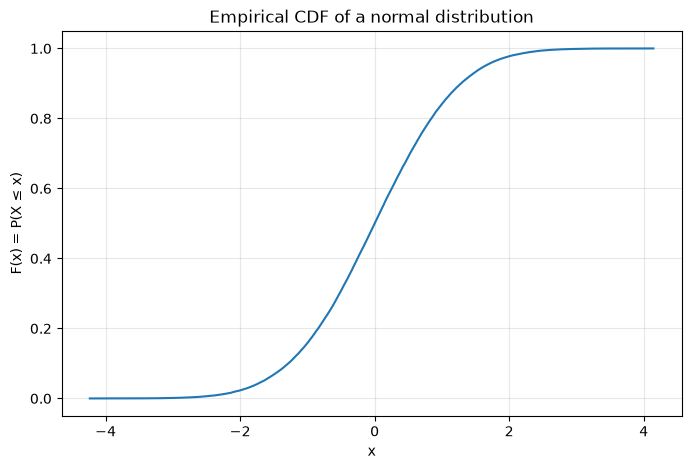

In [97]:
# Empirical CDF from simulated samples

sorted_samples = np.sort(samples)
empirical_cdf = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)

plt.plot(sorted_samples, empirical_cdf)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("Empirical CDF of a normal distribution")
plt.grid(True, alpha=0.3)
plt.show()

Example interpretation:

$$
F(0) = P(X \le 0)
$$

For a standard normal distribution, this should be close to `0.5`.

In [98]:
np.mean(samples <= 0)

np.float64(0.50002)

## 6. PDF and CDF Relationship

For continuous random variables:

$$
F(x) = \int_{-\infty}^{x} f(t)\,dt
$$

The CDF is the accumulated area under the PDF. Conversely:

$$
f(x) = \frac{d}{dx}F(x)
$$

The PDF is the slope of the CDF.

### Simple example: Uniform(0, 1)

The uniform distribution has the simplest possible relationship:

$$
f(x) = 1, \quad 0 \le x \le 1
$$

$$
F(x) = \int_0^x 1 \, dt = x, \quad 0 \le x \le 1
$$

The PDF is flat (constant density). The CDF is a straight line with slope 1 — the area accumulated linearly.

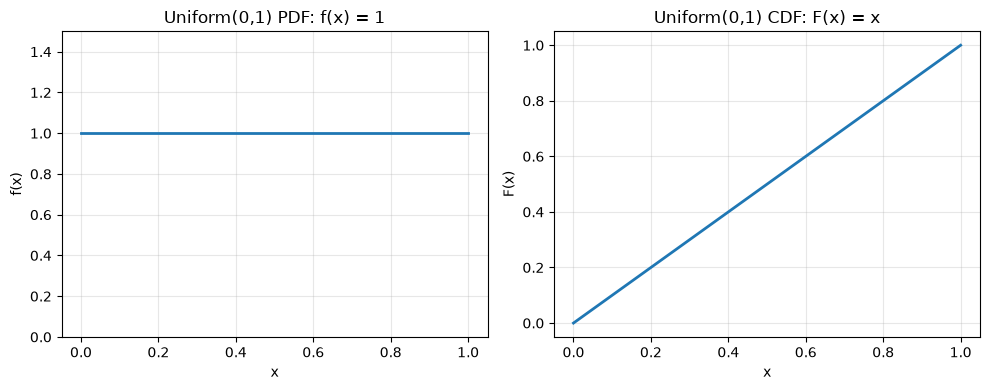

In [99]:
x_uniform = np.linspace(0, 1, 300)
pdf_uniform = np.ones_like(x_uniform)
cdf_uniform = x_uniform

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x_uniform, pdf_uniform, linewidth=2)
axes[0].set_ylim(0, 1.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Uniform(0,1) PDF: f(x) = 1")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_uniform, cdf_uniform, linewidth=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("F(x)")
axes[1].set_title("Uniform(0,1) CDF: F(x) = x")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Normal distribution: numerical approximation

For distributions without a simple closed-form CDF (like the normal), we can approximate it numerically by accumulating the PDF.

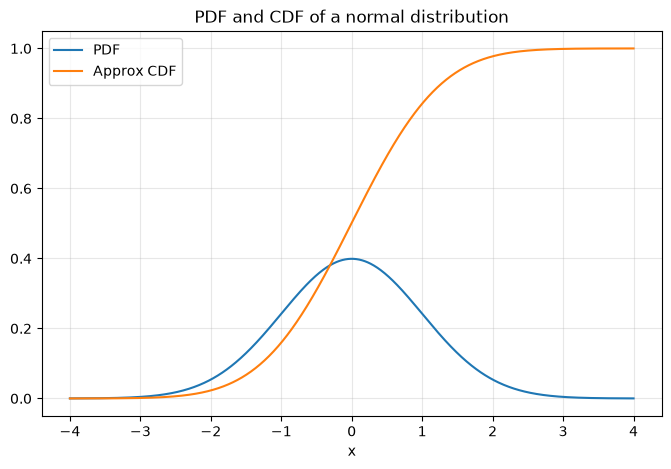

In [100]:
# Numerically approximate the normal CDF from the PDF

x = np.linspace(-4, 4, 1000)
dx = x[1] - x[0]
pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
cdf_approx = np.cumsum(pdf) * dx

plt.plot(x, pdf, label="PDF")
plt.plot(x, cdf_approx, label="Approx CDF")
plt.xlabel("x")
plt.title("PDF and CDF of a normal distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The PDF shows **where probability is concentrated**.

The CDF shows **how much probability has accumulated so far**.

## 7. Key Difference: PMF vs PDF

| Concept | Used for | Meaning | Can give exact value probability? |
|---|---|---|---|
| PMF | Discrete random variables | Probability at a point | Yes: $P(X = x)$ |
| PDF | Continuous random variables | Density at a point | No: probability comes from area |
| CDF | Both discrete and continuous | Cumulative probability | Yes: $P(X \le x)$ |

For a discrete variable, $P(X = x)$ can be positive.

For a continuous variable:

$$
P(X = x) = 0
$$

but:

$$
P(a \le X \le b) > 0
$$

## 8. Uniform Distribution Example

Let $X \sim \text{Uniform}(0, 1)$.

This means every value between 0 and 1 is equally likely in terms of density.

Its PDF is:

$$
f(x) = 1, \quad 0 \le x \le 1
$$

Its CDF is:

$$
F(x) = x, \quad 0 \le x \le 1
$$

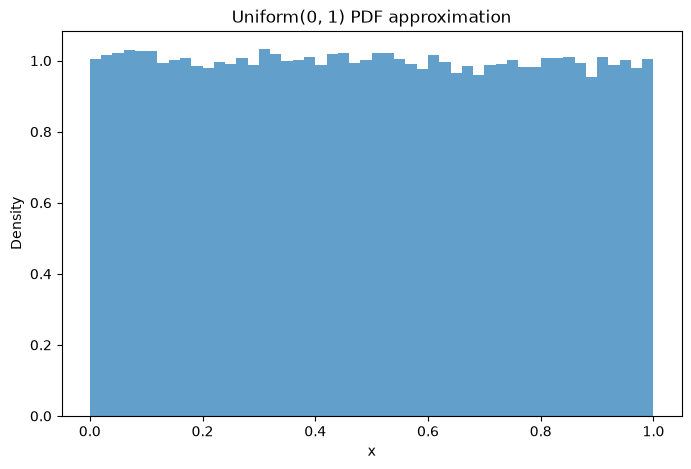

In [101]:
uniform_samples = rng.uniform(0, 1, size=100_000)

plt.hist(uniform_samples, bins=50, density=True, alpha=0.7)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Uniform(0, 1) PDF approximation")
plt.show()

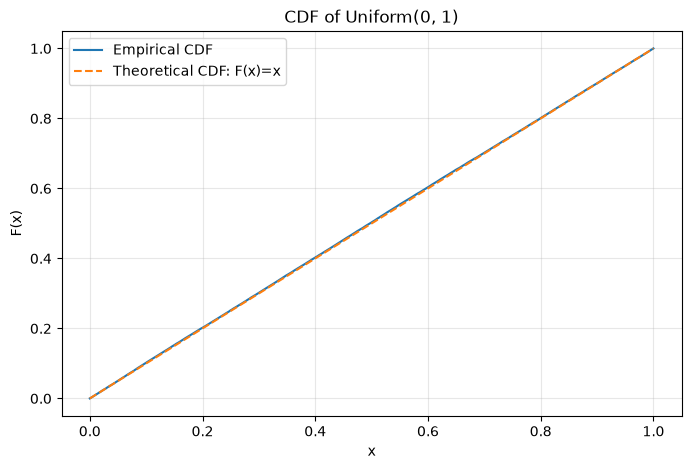

In [102]:
sorted_uniform = np.sort(uniform_samples)
uniform_ecdf = np.arange(1, len(sorted_uniform) + 1) / len(sorted_uniform)

plt.plot(sorted_uniform, uniform_ecdf, label="Empirical CDF")
plt.plot([0, 1], [0, 1], linestyle="--", label="Theoretical CDF: F(x)=x")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF of Uniform(0, 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

For a uniform random variable:

$$
P(0.2 \le X \le 0.5) = 0.5 - 0.2 = 0.3
$$

In [103]:
np.mean((0.2 <= uniform_samples) & (uniform_samples <= 0.5))

np.float64(0.30087)

## 9. Mini Exercise

Try changing the parameters below:

- `p_heads`
- `n_trials`
- `normal_mean`
- `normal_std`

Then rerun the cells and observe how the PMF, PDF, and CDF change.

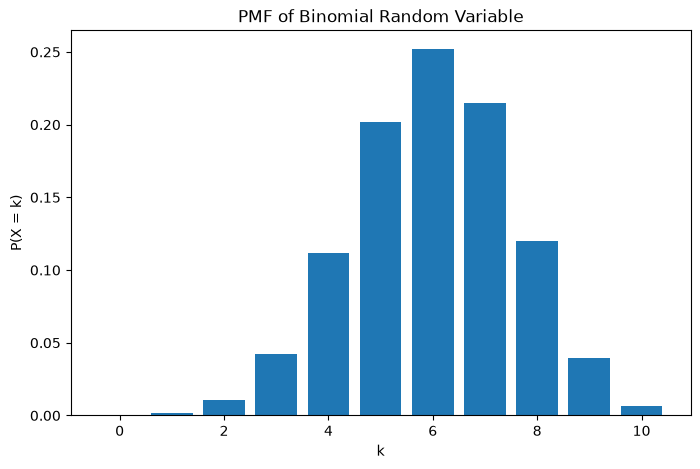

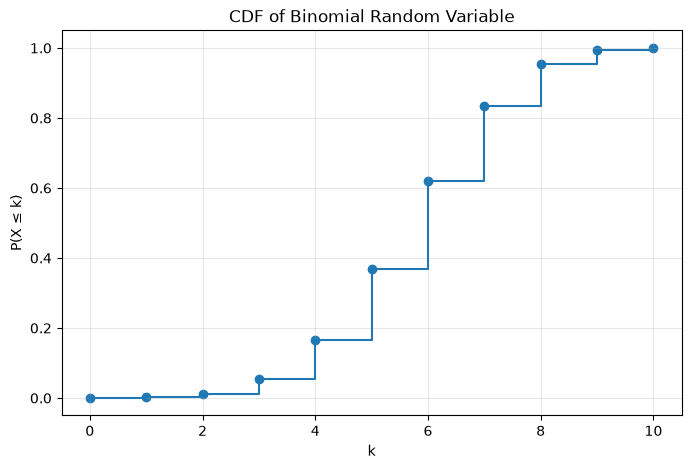

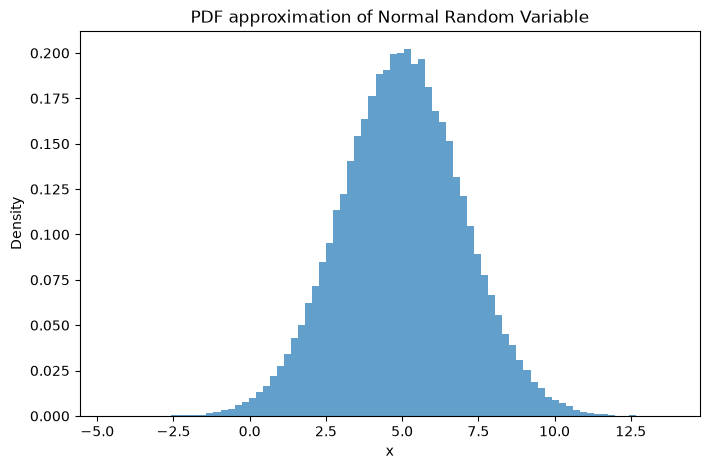

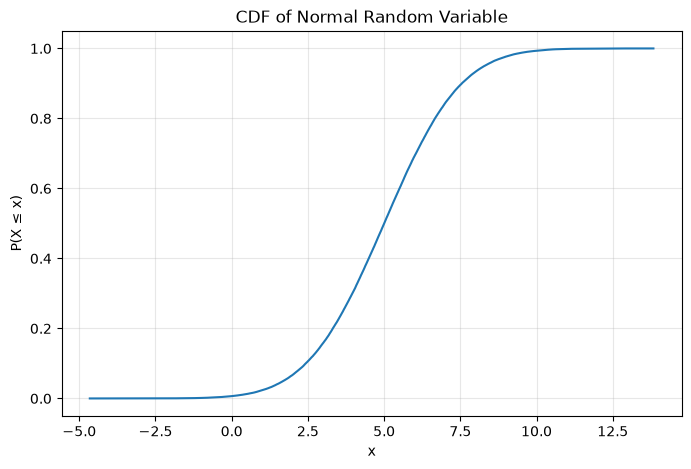

In [104]:
# Experiment cell

p_heads = 0.6
n_trials = 10
normal_mean = 5
normal_std = 2

# Discrete example: Binomial
binomial_samples = rng.binomial(n=n_trials, p=p_heads, size=100_000)
k_values = np.arange(0, n_trials + 1)
sim_pmf = np.array([np.mean(binomial_samples == k) for k in k_values])
sim_cdf = np.cumsum(sim_pmf)

plt.bar(k_values, sim_pmf)
plt.xlabel("k")
plt.ylabel("P(X = k)")
plt.title("PMF of Binomial Random Variable")
plt.show()

plt.step(k_values, sim_cdf, where="post")
plt.scatter(k_values, sim_cdf)
plt.xlabel("k")
plt.ylabel("P(X ≤ k)")
plt.title("CDF of Binomial Random Variable")
plt.grid(True, alpha=0.3)
plt.show()

# Continuous example: Normal
normal_samples = rng.normal(normal_mean, normal_std, size=100_000)

plt.hist(normal_samples, bins=80, density=True, alpha=0.7)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("PDF approximation of Normal Random Variable")
plt.show()

sorted_normal = np.sort(normal_samples)
ecdf = np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)

plt.plot(sorted_normal, ecdf)
plt.xlabel("x")
plt.ylabel("P(X ≤ x)")
plt.title("CDF of Normal Random Variable")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Expected Value and Variance

Once you have a PMF or PDF, two of the most important summary statistics are the **expected value** and **variance**.

The **expected value** $E[X]$ is the mean of the distribution — the long-run average value of the random variable:

$$
E[X] = \sum_x x \cdot P(X = x) \quad \text{(discrete)}
$$

$$
E[X] = \int_{-\infty}^{\infty} x \cdot f(x)\,dx \quad \text{(continuous)}
$$

The **variance** $\text{Var}(X)$ measures spread around the mean:

$$
\text{Var}(X) = E\left[(X - E[X])^2\right]
$$

In [105]:
# Discrete: Binomial(n=3, p=0.7) — recomputed locally to avoid state from the mini exercise
n_binom, p_binom = 3, 0.7
k = np.arange(0, n_binom + 1)
pmf_binom = np.array([
    comb(n_binom, i) * p_binom**i * (1 - p_binom)**(n_binom - i)
    for i in k
])

e_x_discrete = np.sum(k * pmf_binom)
var_x_discrete = np.sum((k - e_x_discrete) ** 2 * pmf_binom)

print("Binomial(n=3, p=0.7)")
print(f"  E[X]    = {e_x_discrete:.4f}  (theoretical n*p = {n_binom * p_binom:.4f})")
print(f"  Var(X)  = {var_x_discrete:.4f}  (theoretical n*p*(1-p) = {n_binom * p_binom * (1 - p_binom):.4f})")

# Continuous: Normal(0, 1) — using samples from Section 4
print()
print("Normal(0, 1)")
print(f"  E[X]    ≈ {np.mean(samples):.4f}  (theoretical: 0)")
print(f"  Var(X)  ≈ {np.var(samples):.4f}  (theoretical: 1)")

Binomial(n=3, p=0.7)
  E[X]    = 2.1000  (theoretical n*p = 2.1000)
  Var(X)  = 0.6300  (theoretical n*p*(1-p) = 0.6300)

Normal(0, 1)
  E[X]    ≈ -0.0005  (theoretical: 0)
  Var(X)  ≈ 1.0002  (theoretical: 1)


The simulated values match the theoretical ones closely.

E[X] and Var(X) can be computed directly from the PMF (discrete) or approximated from samples (continuous). They are the two numbers that most compactly describe the center and spread of any distribution.

## 11. What to Remember for Real Problems

### Choosing the right tool

| Situation | Tool | Why |
|---|---|---|
| Outcomes are countable (coin, die, count) | PMF | $P(X = x)$ is a valid, nonzero probability |
| Outcomes are continuous (time, height, error) | PDF | $P(X = x) = 0$; probability only comes from intervals |
| "At most", "at least", or "between" question | CDF | $F(x) = P(X \le x)$ answers these directly |
| Center or spread of a distribution | $E[X]$, $\text{Var}(X)$ | Summarize the whole distribution in two numbers |

---

### PMF — discrete variables

- $P(X = x)$ gives the exact probability of each value.
- Always verify: $\sum_x P(X = x) = 1$.
- Common distributions: Binomial, Poisson, Geometric.

---

### PDF — continuous variables

- The height of the PDF is **not** a probability — it is density.
- Probability comes from **area**: $P(a \le X \le b) = \int_a^b f(x)\,dx$.
- $P(X = \text{any exact value}) = 0$ — never ask for this.
- Always verify: $\int_{-\infty}^{\infty} f(x)\,dx = 1$.
- Common distributions: Normal, Uniform, Exponential.

---

### CDF — both discrete and continuous

- $F(x) = P(X \le x)$ — always defined, always between 0 and 1.
- Three properties to check: non-decreasing, $F(-\infty) = 0$, $F(\infty) = 1$.
- Interval formula: $P(a < X \le b) = F(b) - F(a)$ — left endpoint is open.
- For continuous variables: $P(a \le X \le b) = F(b) - F(a)$ (open vs closed doesn't matter).
- For discrete variables: open vs closed matters — $P(X = a) > 0$ is possible.

---

### $E[X]$ and $\text{Var}(X)$

- $E[X]$ is the long-run average — the balance point of the distribution.
- $\text{Var}(X)$ is the average squared deviation from the mean.
- Standard deviation $\sigma = \sqrt{\text{Var}(X)}$ is in the same units as $X$ — easier to interpret.
- For a Normal distribution: ~68% of values fall within $1\sigma$, ~95% within $2\sigma$, ~99.7% within $3\sigma$.

---

### Common mistakes

- Using PDF height as a probability — it is density, not probability.
- Forgetting the open left endpoint: $P(a < X \le b) = F(b) - F(a)$, not $F(b) - F(a-1)$.
- Applying a discrete formula to a continuous variable or vice versa.
- Confusing $E[X^2]$ with $E[X]^2$ — these are different: $\text{Var}(X) = E[X^2] - E[X]^2$.

## Summary

A **random variable** maps random outcomes to numbers.

A **PMF** applies to discrete random variables and gives exact probabilities: $P(X = x)$.

A **PDF** applies to continuous random variables and gives density. Probability comes from area:

$$
P(a \le X \le b) = \int_a^b f(x)\,dx
$$

A **CDF** applies to both and gives cumulative probability: $F(x) = P(X \le x)$.

The **expected value** $E[X]$ and **variance** $\text{Var}(X)$ summarize the center and spread of any distribution, computed from the PMF or PDF.

The CDF is often the most universally useful object because it directly answers cumulative probability questions for both discrete and continuous variables.